In [19]:
from langgraph.graph import StateGraph, START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv


In [20]:
load_dotenv()

True

In [21]:
model = ChatOpenAI()

In [22]:
#create a state
class LLMState(TypedDict):

    question:str
    answer:str

In [24]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from the state 
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM 
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state;


In [30]:
#create a graph 
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa',llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile 
workflow = graph.compile();

In [31]:
initial_state = {'question': 'How far is moon from the earth ?'}
output_state = workflow.invoke(initial_state);

print(output_state)


OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

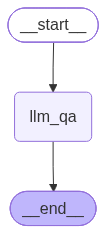

In [32]:
#view the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())